In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

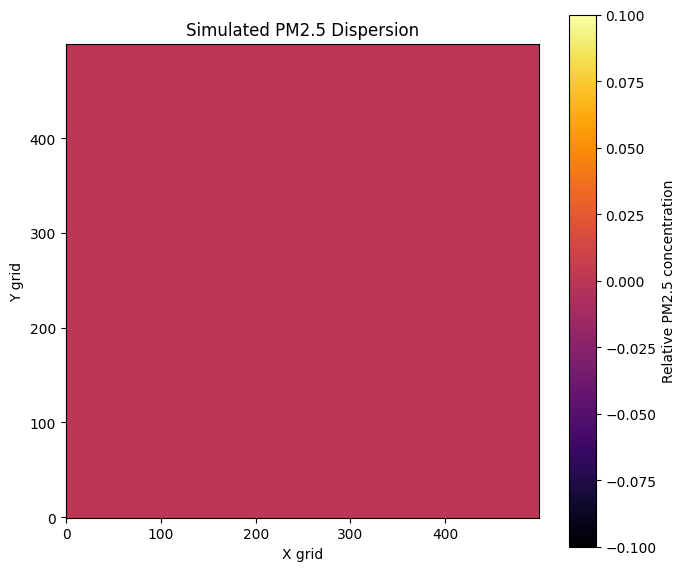

In [9]:
# -----------------------------
# CONFIG
# -----------------------------
DT = 300                 # time step (seconds)
TOTAL_HOURS = 24
PARTICLES_PER_FIRE = 10000
WIND_U = 3.0             # m/s (east)
WIND_V = 0            # m/s (north)
DIFFUSION = 30           # m^2/s
GRID_SIZE = 500
GRID_RES = 200           # meters per grid cell

# -----------------------------
# HELPERS
# -----------------------------
def latlon_to_xy(lat, lon, lat0, lon0):
    """Convert lat/lon to local meters"""
    R = 6371000
    x = np.radians(lon - lon0) * R * np.cos(np.radians(lat0))
    y = np.radians(lat - lat0) * R
    return x, y

# -----------------------------
# LOAD FIRE DATA
# -----------------------------
fires = pd.read_csv("sample_fires.csv")
fires["start_time"] = pd.to_datetime(fires["start_time"])
fires["end_time"] = pd.to_datetime(fires["end_time"])

lat0, lon0 = fires.iloc[0][["lat", "lon"]]

# -----------------------------
# INITIALIZE PARTICLES
# -----------------------------
particles_x = []
particles_y = []

for _, row in fires.iterrows():
    n = int(PARTICLES_PER_FIRE * row.emission_rate)
    x0, y0 = latlon_to_xy(row.lat, row.lon, lat0, lon0)
    particles_x.append(np.full(n, x0))
    particles_y.append(np.full(n, y0))

x = np.concatenate(particles_x)
y = np.concatenate(particles_y)

# -----------------------------
# TIME INTEGRATION
# -----------------------------
steps = int(TOTAL_HOURS * 3600 / DT)

for _ in range(steps):
    x += WIND_U * DT + np.sqrt(2 * DIFFUSION * DT) * np.random.randn(len(x))
    y += WIND_V * DT + np.sqrt(2 * DIFFUSION * DT) * np.random.randn(len(y))

# -----------------------------
# GRID CONCENTRATION
# -----------------------------
H, xedges, yedges = np.histogram2d(
    x, y,
    bins=GRID_SIZE,
    range=[
        [-GRID_SIZE * GRID_RES / 2, GRID_SIZE * GRID_RES / 2],
        [-GRID_SIZE * GRID_RES / 2, GRID_SIZE * GRID_RES / 2]
    ]
)

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(7, 6))
plt.imshow(H.T, origin="lower", cmap="inferno")
plt.colorbar(label="Relative PM2.5 concentration")
plt.title("Simulated PM2.5 Dispersion")
plt.xlabel("X grid")
plt.ylabel("Y grid")
plt.tight_layout()
plt.show()


In [54]:
data = pd.read_csv(r'data\fire_archive_J1V-C2_696273.csv')
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,25.39488,91.32134,326.99,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,288.68,5.23,D,0
1,23.77677,94.15546,327.00,0.38,0.58,2024-01-01,613,N20,VIIRS,n,2,295.45,2.07,D,0
2,25.39434,91.32460,333.95,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,286.02,4.16,D,0
3,24.82792,93.75638,339.55,0.38,0.59,2024-01-01,613,N20,VIIRS,n,2,288.58,4.46,D,0
4,24.67892,94.56968,330.12,0.34,0.56,2024-01-01,613,N20,VIIRS,n,2,293.73,2.29,D,0


In [55]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2 + 
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * 
         math.sin(dlon/2)**2)
    return 2 * R * math.asin(math.sqrt(a))

# Delhi centroid example: ~28.66°N, 77.21°E
dist = haversine(28.61, 77.23, 28.66, 77.21)  # ~6 km
dist

5.8924248398293715

In [57]:
distances = []

# delhi
delhi_lat = 28.6139
delhi_long = 77.2090

for index, row in data.iterrows():
	fire_lat = row['latitude']
	fire_lon = row['longitude']
	distance = haversine(fire_lat, fire_lon, delhi_lat, delhi_long)
	distances.append(distance)

In [58]:
data['dist_to_delhi'] = distances
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,dist_to_delhi
0,25.39488,91.32134,326.99,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,288.68,5.23,D,0,1442.195731
1,23.77677,94.15546,327.00,0.38,0.58,2024-01-01,613,N20,VIIRS,n,2,295.45,2.07,D,0,1772.333338
2,25.39434,91.32460,333.95,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,286.02,4.16,D,0,1442.526095
3,24.82792,93.75638,339.55,0.38,0.59,2024-01-01,613,N20,VIIRS,n,2,288.58,4.46,D,0,1694.911749
4,24.67892,94.56968,330.12,0.34,0.56,2024-01-01,613,N20,VIIRS,n,2,293.73,2.29,D,0,1778.133163


In [59]:
# Expanded North India bounds
lat_min, lat_max = 27.0, 34.5
lon_min, lon_max = 71.0, 77.5

punjab_df = data[
    (data["latitude"] >= lat_min) &
    (data["latitude"] <= lat_max) &
    (data["longitude"] >= lon_min) &
    (data["longitude"] <= lon_max)
]
punjab_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,dist_to_delhi
758,28.08708,76.89363,338.92,0.39,0.36,2024-01-01,755,N20,VIIRS,n,2,289.54,6.08,D,0,66.211801
785,31.61615,77.42566,328.49,0.39,0.36,2024-01-01,756,N20,VIIRS,n,2,288.61,3.55,D,0,334.484493
789,31.31871,77.00268,341.60,0.38,0.36,2024-01-01,756,N20,VIIRS,n,2,298.21,3.47,D,0,301.416876
796,31.59105,76.71239,333.82,0.38,0.36,2024-01-01,756,N20,VIIRS,n,2,296.47,2.60,D,0,334.471717
805,31.30301,77.10055,333.64,0.38,0.36,2024-01-01,756,N20,VIIRS,n,2,294.27,2.30,D,0,299.197795


In [60]:
min(punjab_df['acq_date'])

'2024-01-01'

In [40]:
len(punjab_df)
punjab_df.isnull().sum()

latitude         0
longitude        0
brightness       0
scan             0
track            0
acq_date         0
acq_time         0
satellite        0
instrument       0
confidence       0
version          0
bright_t31       0
frp              0
daynight         0
type             0
dist_to_delhi    0
dtype: int64

In [11]:
max(punjab_df['acq_date'])

'2025-01-01'

In [61]:
data["acq_date"].min(), data["acq_date"].max(), data["acq_date"].nunique()


('2024-01-01', '2025-01-01', 366)

In [21]:
punjab_df.to_csv(r'data\punjab_fires_2021_2025.csv', index=False)

In [12]:
wind_df = pd.read_csv(r'data\wind_speed_tel_hr_punjab_sw_pb_1970_2025.csv')
wind_df.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr)
0,1,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,Satluj,Indus,-,-,-,Satluj,30.140833,74.207778,27-12-1999 00:00,0.0
1,2,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,Satluj,Indus,-,-,-,Satluj,30.140833,74.207778,28-12-1999 00:00,0.0
2,3,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,Satluj,Indus,-,-,-,Satluj,30.140833,74.207778,29-12-1999 00:00,0.0
3,4,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,Satluj,Indus,-,-,-,Satluj,30.140833,74.207778,30-12-1999 00:00,0.0
4,5,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,Satluj,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 18:57,40.4


In [16]:
wind_df['acq_date'] = pd.to_datetime(wind_df['Data Acquisition Time'], format='%d-%m-%Y %H:%M')
wind_df["acq_date"] = pd.to_datetime(wind_df["Data Acquisition Time"]).dt.date


C:\Users\Atharva Taras\AppData\Local\Temp\ipykernel_25548\442726847.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  wind_df["acq_date"] = pd.to_datetime(wind_df["Data Acquisition Time"]).dt.date


In [17]:
wind_df.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,...,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr),acq_date
0,1,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,27-12-1999 00:00,0.0,1999-12-27
1,2,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,28-12-1999 00:00,0.0,1999-12-28
2,3,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,29-12-1999 00:00,0.0,1999-12-29
3,4,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,30-12-1999 00:00,0.0,1999-12-30
4,5,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 18:57,40.4,2021-04-12


In [19]:
wind_df = wind_df[
    (pd.to_datetime(wind_df['acq_date']) >= '2021-01-01') &
    (pd.to_datetime(wind_df['acq_date']) <= '2025-01-01')
]


In [20]:
wind_df.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,...,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Wind Speed (Km/Hr),acq_date
4,5,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 18:57,40.4,2021-04-12
5,6,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 19:57,38.0,2021-04-12
6,7,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 20:57,35.6,2021-04-12
7,8,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 21:57,34.4,2021-04-12
8,9,Abohar,Punjab SW,3,Punjab,31,FEROZEPUR,Abohar,-,-,...,Indus,-,-,-,Satluj,30.140833,74.207778,12-04-2021 22:57,30.8,2021-04-12


In [35]:
wind_df.columns

Index(['SlNo', 'Station', 'Agency', 'State LGD Code', 'State',
       'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River',
       'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River',
       'Latitude', 'Longitude', 'Data Acquisition Time',
       'Telemetry Hourly Wind Speed (Km/Hr)', 'acq_date'],
      dtype='object')

In [36]:
wind_df.drop(columns=['SlNo', 'Station', 'Agency', 'State LGD Code', 'State',
       'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River',
       'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River'], inplace=True)

In [41]:
wind_df.duplicated().sum()

np.int64(0)

In [39]:
wind_df.to_csv(r'data\punjab_wind_2021_2025.csv', index=False)

In [27]:
aqi_df = pd.read_csv(r'data\delhi_aqi_new.csv')
aqi_df.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [30]:
aqi_df["acq_date"] = pd.to_datetime({
    "year": aqi_df["Year"],
    "month": aqi_df["Month"],
    "day": aqi_df["Date"],
}).dt.date


aqi_df.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI,acq_date
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462,2021-01-01
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482,2021-01-02
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263,2021-01-03
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207,2021-01-04
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149,2021-01-05


In [31]:
aqi_df.drop(columns=['Year', 'Month', 'Date'], inplace=True)

In [32]:
aqi_df.rename(columns={'Days ': 'day_of_week'}, inplace=True)

In [34]:
aqi_df.to_csv(r'data\delhi_aqi_2021_2024.csv', index=False)

In [42]:
aqi_df.duplicated().sum()

np.int64(0)

In [44]:
weather_df = pd.read_csv(r'data\kaggel_weather_2013_to_2024.csv')
weather_df.head()

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,4/14/2013,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,4/15/2013,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,4/16/2013,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,4/17/2013,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,4/18/2013,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [46]:
weather_df = weather_df[
	(pd.to_datetime(weather_df['DATE']) >= '2021-01-01')]
weather_df.head()

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
2128,2128,1/1/2021,18.1,3.7,10.2,18.1,3.7,10.2,79.2,0.000,...,21,53,1433.52,293.04,807.84,1433.52,293.04,807.84,14.4,319.136909
2129,2129,1/2/2021,19.0,7.8,13.4,19.0,7.8,13.4,77.8,0.911,...,21,53,1478.20,606.84,1042.52,1478.20,606.84,1042.52,11.2,291.062565
2130,2130,1/3/2021,17.0,11.1,13.9,17.0,11.1,13.9,90.1,36.462,...,21,53,1531.70,1000.11,1252.39,1531.70,1000.11,1252.39,5.9,286.708959
2131,2131,1/4/2021,21.6,12.2,16.2,21.6,12.2,16.2,94.2,5.598,...,21,1,2034.72,1149.24,1526.04,2034.72,1149.24,1526.04,9.4,263.446575
2132,2132,1/5/2021,20.6,14.5,17.1,20.6,14.5,17.1,93.8,1.280,...,21,1,1932.28,1360.10,1603.98,1932.28,1360.10,1603.98,6.1,256.187200


In [47]:
weather_df.columns

Index(['Unnamed: 0', 'DATE', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'humidity', 'precip', 'precipprob',
       'precipcover', 'windspeed', 'sealevelpressure', 'conditions', 'Year',
       'month', 'dayofweek', 'dayofyear', 'year-2000', 'weekofyear',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity',
       'feelslikemax_humidity', 'feelslikemin_humidity', 'feelslike_humidity',
       'temp_range', 'heat_index'],
      dtype='object')

In [49]:
weather_df.drop(columns=['Unnamed: 0', 'feelslikemax_humidity', 'feelslikemin_humidity', 'feelslike_humidity', 'Year',
       'month', 'dayofweek', 'dayofyear', 'year-2000', 'weekofyear',], inplace=True)

C:\Users\Atharva Taras\AppData\Local\Temp\ipykernel_25548\4057064649.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df.drop(columns=['Unnamed: 0', 'feelslikemax_humidity', 'feelslikemin_humidity', 'feelslike_humidity', 'Year',


In [50]:
weather_df.head()

,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,windspeed,sealevelpressure,conditions,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index
2128,1/1/2021,18.1,3.7,10.2,18.1,3.7,10.2,79.2,0.000,0,0.00,11.2,1017.9,Clear,1433.52,293.04,807.84,14.4,319.136909
2129,1/2/2021,19.0,7.8,13.4,19.0,7.8,13.4,77.8,0.911,100,8.33,16.6,1016.1,"Rain, Partially cloudy",1478.20,606.84,1042.52,11.2,291.062565
2130,1/3/2021,17.0,11.1,13.9,17.0,11.1,13.9,90.1,36.462,100,12.50,16.6,1014.6,"Rain, Partially cloudy",1531.70,1000.11,1252.39,5.9,286.708959
2131,1/4/2021,21.6,12.2,16.2,21.6,12.2,16.2,94.2,5.598,100,12.50,18.4,1016.1,"Rain, Partially cloudy",2034.72,1149.24,1526.04,9.4,263.446575
2132,1/5/2021,20.6,14.5,17.1,20.6,14.5,17.1,93.8,1.280,100,8.33,14.8,1015.5,"Rain, Partially cloudy",1932.28,1360.10,1603.98,6.1,256.187200


In [51]:
weather_df.isnull().sum()

DATE                0
tempmax             0
tempmin             0
temp                0
feelslikemax        0
feelslikemin        0
feelslike           0
humidity            0
precip              0
precipprob          0
precipcover         0
windspeed           0
sealevelpressure    0
conditions          0
tempmax_humidity    0
tempmin_humidity    0
temp_humidity       0
temp_range          0
heat_index          0
dtype: int64

In [52]:
weather_df.to_csv(r'data\delhi_weather_2021_2024.csv', index=False)

In [4]:
nasa_df = pd.read_csv(r'data\nasa_fire_dataset.csv')
nasa_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,20.98736,86.20535,328.18,0.43,0.62,2021-01-01,643,N20,VIIRS,n,2,299.98,1.35,D,0
1,20.96260,85.17462,339.58,0.50,0.66,2021-01-01,643,N20,VIIRS,n,2,297.19,10.44,D,2
2,21.07877,85.04145,331.57,0.51,0.66,2021-01-01,643,N20,VIIRS,n,2,298.91,3.19,D,2
3,20.91675,86.43446,333.87,0.42,0.61,2021-01-01,643,N20,VIIRS,n,2,299.64,2.96,D,0
4,21.15114,86.66348,340.05,0.40,0.60,2021-01-01,643,N20,VIIRS,n,2,299.39,6.59,D,0


In [6]:
# Expanded North India bounds
lat_min, lat_max = 27.0, 34.5
lon_min, lon_max = 71.0, 77.5

fire_df = nasa_df[
    (nasa_df["latitude"] >= lat_min) &
    (nasa_df["latitude"] <= lat_max) &
    (nasa_df["longitude"] >= lon_min) &
    (nasa_df["longitude"] <= lon_max)
]


In [7]:
min(fire_df['acq_date']), max(fire_df['acq_date'])

('2021-01-01', '2025-01-01')

In [12]:
distances = []

import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2 + 
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * 
         math.sin(dlon/2)**2)
    return 2 * R * math.asin(math.sqrt(a))

# delhi
delhi_lat = 28.6139
delhi_long = 77.2090

for index, row in fire_df.iterrows():
	fire_lat = row['latitude']
	fire_lon = row['longitude']
	distance = haversine(fire_lat, fire_lon, delhi_lat, delhi_long)
	distances.append(distance)

fire_df['dist_to_delhi'] = distances

C:\Users\Atharva Taras\AppData\Local\Temp\ipykernel_7888\3694193750.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fire_df['dist_to_delhi'] = distances


In [13]:
fire_df.to_csv(r'A:\Software Projects\Delhi-AQI-Model\data\punjab_fires_2021_2025.csv', index=False)